# FinTrust Week 2 — Python Exploratory Data Analysis

**Track:** Data Analytics  
**Project:** FinTrust Financial Intelligence & Digital Banking Support Solution

This notebook implements the Week 2 requirement to perform exploratory analysis, produce at least five meaningful visualizations, explain their importance, and document limitations. The data is a synthetic educational sample.

### Critical Week 1 issue carried forward
The visible transaction/customer key relationship is not reliable: only **1 of 33** transaction Customer_IDs matches the visible customer export. Therefore, this notebook keeps customer and transaction analysis separate unless a join is explicitly used for the one matched record. Customer-level transaction conclusions are not generalized from the current join.

The supplied transaction export also does not contain `Transaction_Status` or `Risk_Review_Flag`, so those analyses are documented as unavailable rather than fabricated.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 120

customers = pd.read_csv('../data/FinTrust_Customer_Data_Week2.csv')
transactions = pd.read_csv('../data/FinTrust_Transaction_Data_Week2.csv', parse_dates=['Transaction_DateTime'])

print('Customers:', customers.shape)
print('Transactions:', transactions.shape)


Customers: (33, 6)
Transactions: (33, 6)


## 1. Data Quality Checks

In [2]:
customer_cols = ['Customer_ID','Customer_Name','Age','Gender','City','Customer_Segment']
transaction_cols = ['Transaction_ID','Customer_ID','Transaction_DateTime','Transaction_Type','Amount_NGN','Channel']

quality = pd.DataFrame({
    'Customer_Missing': customers[customer_cols].isna().sum(),
})
print('Customer missing values:', '\n', customers[customer_cols].isna().sum())
print('Customer duplicate IDs:', customers['Customer_ID'].duplicated().sum())
print('Transaction missing values:', '\n', transactions[transaction_cols].isna().sum())
print('Transaction duplicate IDs:', transactions['Transaction_ID'].duplicated().sum())

match_rate = transactions['Customer_ID'].isin(customers['Customer_ID']).mean()
print(f'Customer_ID match rate: {match_rate:.1%}')


Customer missing values: 
 Customer_ID         0
Customer_Name       0
Age                 0
Gender              0
City                0
Customer_Segment    0
dtype: int64
Customer duplicate IDs: 0
Transaction missing values: 
 Transaction_ID          0
Customer_ID             0
Transaction_DateTime    0
Transaction_Type        0
Amount_NGN              0
Channel                 0
dtype: int64
Transaction duplicate IDs: 0
Customer_ID match rate: 3.0%


## 2. Customer Segment Distribution

**What it shows:** the composition of the visible customer sample.

**Why it matters:** segment mix helps frame the population represented in the sample.

**Business insight:** Everyday is the largest visible segment, followed by Premium. This can guide segmentation-focused dashboard views, but it should not be treated as a population-wide FinTrust distribution.

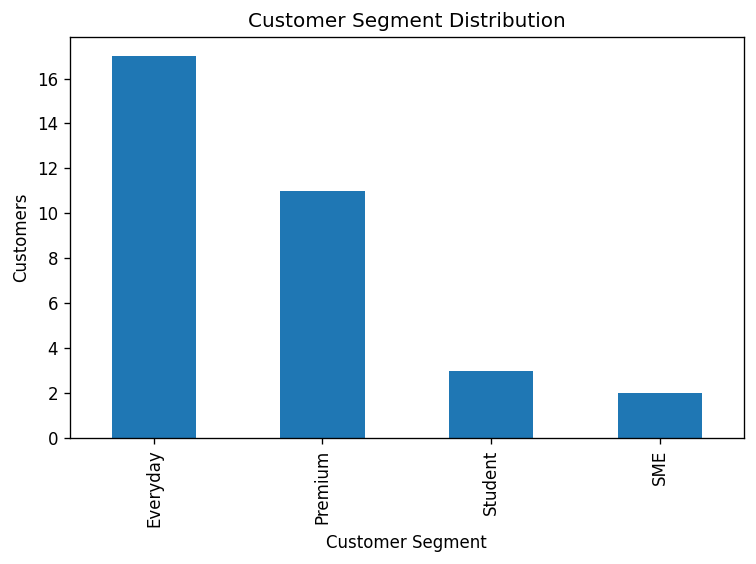

In [3]:
segment_counts = customers['Customer_Segment'].value_counts()
ax = segment_counts.plot(kind='bar')
ax.set_xlabel('Customer Segment'); ax.set_ylabel('Customers'); ax.set_title('Customer Segment Distribution')
plt.tight_layout(); plt.show()


## 3. Transaction Channel Usage

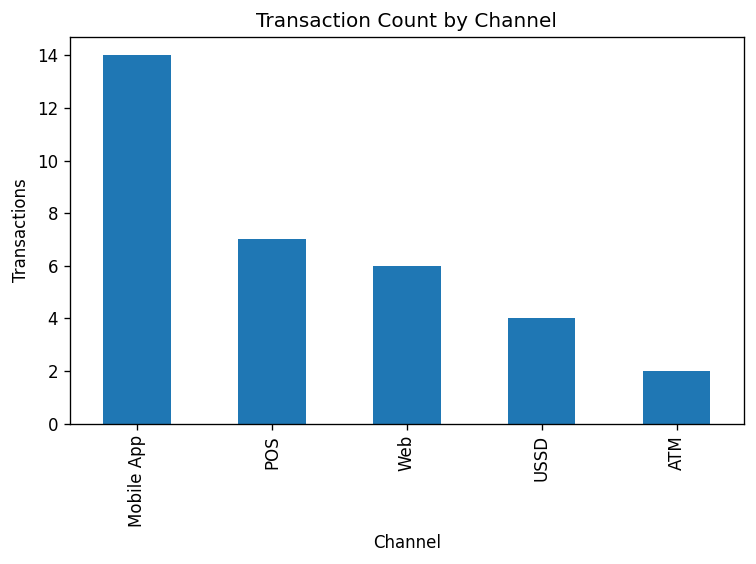

In [4]:
channel_counts = transactions['Channel'].value_counts()
ax = channel_counts.plot(kind='bar')
ax.set_xlabel('Channel'); ax.set_ylabel('Transactions'); ax.set_title('Transaction Count by Channel')
plt.tight_layout(); plt.show()


**Interpretation:** Mobile App accounts for 14 of 33 transactions (42.4%), making it the most-used channel in the sample.

## 4. Transaction Value by Channel

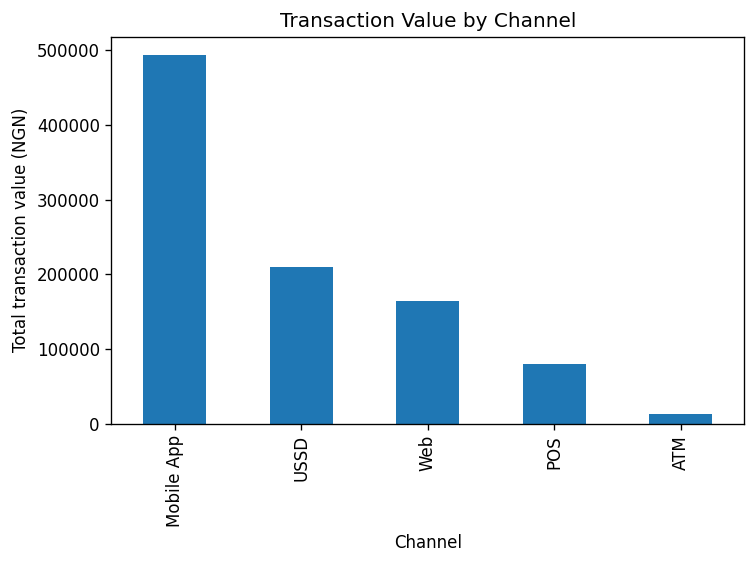

In [5]:
channel_value = transactions.groupby('Channel')['Amount_NGN'].sum().sort_values(ascending=False)
ax = channel_value.plot(kind='bar')
ax.set_xlabel('Channel'); ax.set_ylabel('Total transaction value (NGN)'); ax.set_title('Transaction Value by Channel')
plt.tight_layout(); plt.show()


**Interpretation:** Mobile App carries NGN 493,341.73 of transaction value. USSD has fewer transactions than POS/Web but higher total value than both, showing why volume and value should be monitored separately.

## 5. Transaction Value by Type

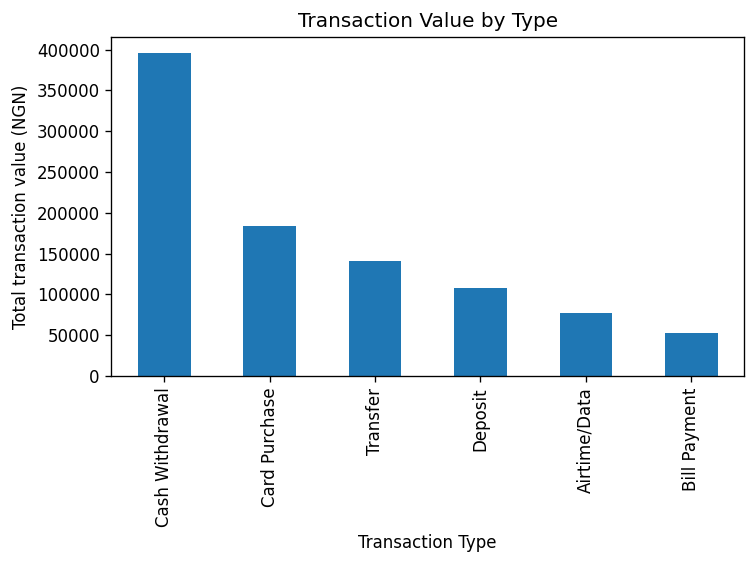

In [6]:
type_value = transactions.groupby('Transaction_Type')['Amount_NGN'].sum().sort_values(ascending=False)
ax = type_value.plot(kind='bar')
ax.set_xlabel('Transaction Type'); ax.set_ylabel('Total transaction value (NGN)'); ax.set_title('Transaction Value by Type')
plt.tight_layout(); plt.show()


**Interpretation:** Cash Withdrawal contributes the largest transaction value in this sample at NGN 395,660.05. This makes cash withdrawal activity a useful management view, while remembering that the sample is small.

## 6. Transaction Amount Distribution / Outliers

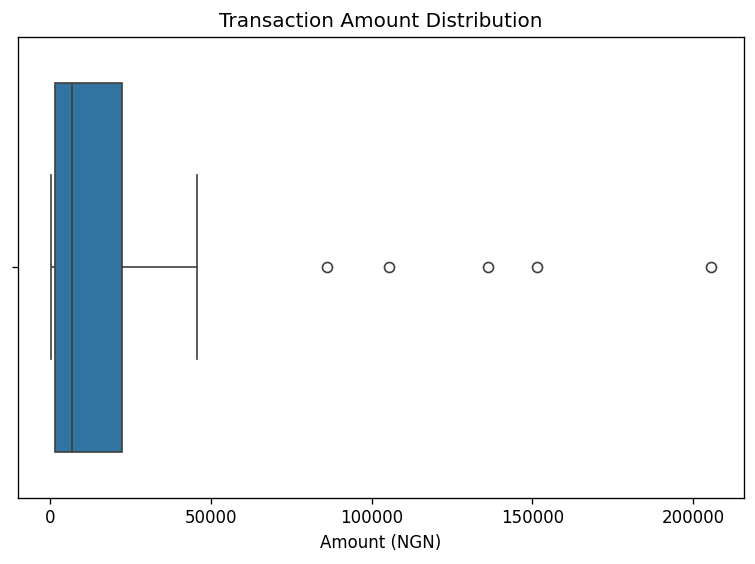

Q1: NGN 1,494.62
Median: NGN 6,702.14
Q3: NGN 22,208.35
IQR upper threshold: NGN 53,278.94
Potential IQR outliers:


,Transaction_ID,Amount_NGN,Transaction_Type,Channel
10,FT-T000011,205633.39,Cash Withdrawal,USSD
32,FT-T000033,151362.75,Card Purchase,Mobile App
24,FT-T000025,136149.30,Cash Withdrawal,Web
3,FT-T000004,105367.52,Deposit,Mobile App
20,FT-T000021,86152.38,Transfer,Mobile App


In [7]:
q1 = transactions['Amount_NGN'].quantile(0.25)
q3 = transactions['Amount_NGN'].quantile(0.75)
iqr = q3-q1
upper = q3 + 1.5*iqr

# Seaborn is used here for the required EDA tooling.
sns.boxplot(x=transactions['Amount_NGN'])
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount (NGN)')
plt.tight_layout(); plt.show()

print(f'Q1: NGN {q1:,.2f}')
print(f'Median: NGN {transactions["Amount_NGN"].median():,.2f}')
print(f'Q3: NGN {q3:,.2f}')
print(f'IQR upper threshold: NGN {upper:,.2f}')
print('Potential IQR outliers:')
display(transactions.loc[transactions['Amount_NGN'] > upper, ['Transaction_ID','Amount_NGN','Transaction_Type','Channel']].sort_values('Amount_NGN', ascending=False))


**Interpretation:** the mean (NGN 29,066.07) is much higher than the median (NGN 6,702.14), indicating a right-skewed distribution. Five transactions exceed the IQR-based upper threshold of about NGN 53,278.95. These should be validated rather than automatically removed.

## 7. Transaction Activity by Hour

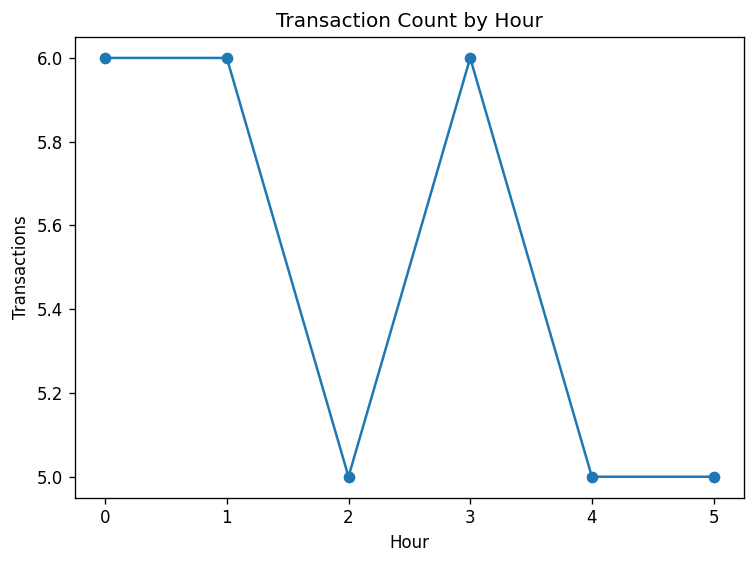

      Transaction_Count  Total_Value_NGN
Hour                                    
0                     6        126769.30
1                     6        274314.43
2                     5         45757.09
3                     6        136711.91
4                     5        146500.28
5                     5        229127.42


In [8]:
transactions['Hour'] = transactions['Transaction_DateTime'].dt.hour
hourly = transactions.groupby('Hour').agg(Transaction_Count=('Transaction_ID','count'), Total_Value_NGN=('Amount_NGN','sum'))
ax = hourly['Transaction_Count'].plot(kind='line', marker='o')
ax.set_xlabel('Hour'); ax.set_ylabel('Transactions'); ax.set_title('Transaction Count by Hour')
plt.tight_layout(); plt.show()
print(hourly)


**Interpretation:** the sample contains transactions only from 00:00 through 05:45 on 1 January 2026. This means hourly patterns are descriptive of the supplied extract, not evidence of full-day or ongoing customer behaviour.

## 8. Limitations and Unavailable Analyses

- `Transaction_Status` is absent from the supplied transaction export, so success-rate analysis cannot be calculated.
- `Risk_Review_Flag` is absent from the supplied transaction export, so risk-review pattern analysis cannot be calculated.
- Only 1/33 transaction Customer_IDs matches the visible customer dataset; customer-level transaction behaviour is therefore not reliable.
- The data dictionary lists additional customer fields such as Account_Type, Tenure_Months, Digital_Engagement_Score, Monthly_Income_Band, Preferred_Channel and Account_Status, but those fields are not present in the supplied customer export.
- The dataset covers one visible date and 33 transactions, so trend conclusions are limited.

### Week 2 decision
Do not impute or invent unavailable status/risk fields. Flag the source relationship and missing fields for resolution before deeper dashboard analysis.